During the actual implementation of the optimized function, do not forget to the compile all jit functions one time before the loop. call this function: warm_up_jit_functions().

JIT functions warmed up for L=6.


Running iterations: 100%|██████████| 100/100 [02:18<00:00,  1.38s/it]      


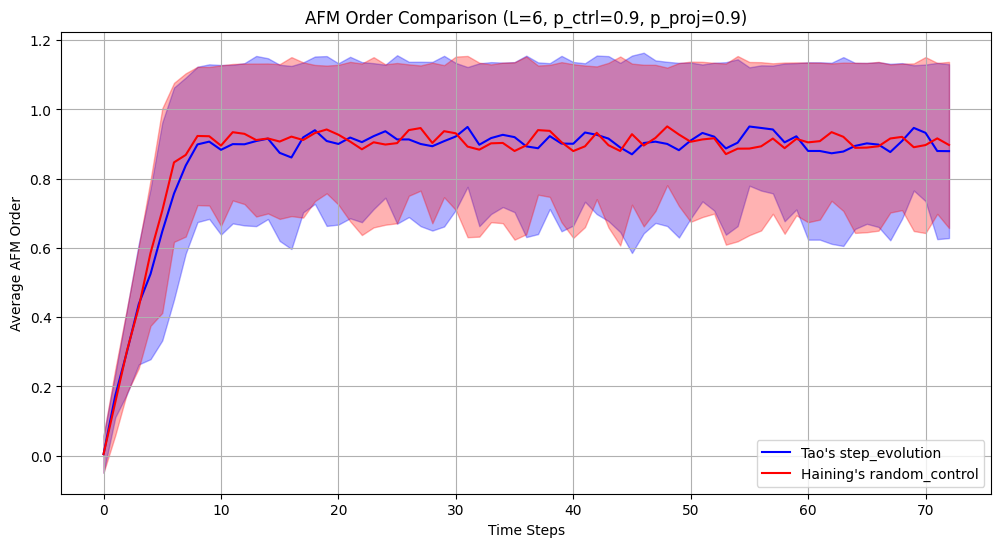

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from corrected_functions import step_evolution, Haar_state, calculate_afm_neel_order, warmup_jit_functions
from haining_correct_functions import random_control

def compare_afm_order(L, num_time_steps, num_iterations, p_ctrl, p_proj):
    # Warm up JIT functions
    warmup_jit_functions(L)
    
    # Initialize arrays to store AFM order values
    tao_afm_orders = np.zeros((num_iterations, num_time_steps + 1))
    haining_afm_orders = np.zeros((num_iterations, num_time_steps + 1))
    
    for iteration in tqdm(range(num_iterations), desc=f"Running iterations"):
        # Initialize random state
        initial_state = Haar_state(L, ensemble=1, rng=np.random.default_rng(), k=1).flatten()
        
        # Tao's step_evolution
        tao_state = initial_state.copy()
        tao_afm_orders[iteration, 0] = calculate_afm_neel_order(tao_state, L)
        for t in range(1, num_time_steps + 1):
            tao_state, _ = step_evolution(tao_state, L, p_ctrl, p_proj)
            tao_afm_orders[iteration, t] = calculate_afm_neel_order(tao_state, L)
        
        # Haining's random_control
        haining_state = initial_state.copy()
        haining_afm_orders[iteration, 0] = calculate_afm_neel_order(haining_state, L)
        for t in range(1, num_time_steps + 1):
            haining_state, _ = random_control(haining_state, p_ctrl, p_proj, L)
            haining_afm_orders[iteration, t] = calculate_afm_neel_order(haining_state, L)
    
    # Calculate mean and standard deviation
    tao_mean = np.mean(tao_afm_orders, axis=0)
    tao_std = np.std(tao_afm_orders, axis=0)
    haining_mean = np.mean(haining_afm_orders, axis=0)
    haining_std = np.std(haining_afm_orders, axis=0)
    
    # Plot results
    time_steps = np.arange(num_time_steps + 1)
    plt.figure(figsize=(12, 6))
    plt.plot(time_steps, tao_mean, label="Tao's step_evolution", color='blue')
    plt.fill_between(time_steps, tao_mean - tao_std, tao_mean + tao_std, alpha=0.3, color='blue')
    plt.plot(time_steps, haining_mean, label="Haining's random_control", color='red')
    plt.fill_between(time_steps, haining_mean - haining_std, haining_mean + haining_std, alpha=0.3, color='red')
    
    plt.xlabel('Time Steps')
    plt.ylabel('Average AFM Order')
    plt.title(f'AFM Order Comparison (L={L}, p_ctrl={p_ctrl}, p_proj={p_proj})')
    plt.legend()
    plt.grid(True)
    plt.show()

# Run comparison
L = 6
num_time_steps = 2 * (L ** 2)
num_iterations = 100
p_ctrl = 0.9
p_proj = 0.9

compare_afm_order(L, num_time_steps, num_iterations, p_ctrl, p_proj)